In [102]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [103]:
#load the data
df=pd.read_excel('medical expenses.xlsx')
df.head()

,age,sex,bmi,children,smoker,region,expenses
0,19,female,27.9,0,yes,southwest,16884.92
1,18,male,33.8,1,no,southeast,1725.55
2,28,male,33.0,3,no,southeast,4449.46
3,33,male,22.7,0,no,northwest,21984.47
4,32,male,28.9,0,no,northwest,3866.86


In [104]:
# Check null values
print(df.isnull().sum())

# Convert categorical → numerical
df = pd.get_dummies(df, drop_first=True)

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
expenses    0
dtype: int64


In [105]:
#separate the x and y values
X = df.drop("expenses", axis=1)
y = df["expenses"]

In [106]:
# split the data
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42)

In [107]:
#Linear regression
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

In [108]:
#Polynomial Regression
poly = PolynomialFeatures(degree=2)

X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

poly_model = LinearRegression()
poly_model.fit(X_train_poly, y_train)

y_pred_poly = poly_model.predict(X_test_poly)

In [109]:
#Ridge regression
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)

y_pred_ridge = ridge.predict(X_test)

In [110]:
#Lasso regression
lasso = Lasso(alpha=0.1)
lasso.fit(X_train, y_train)

y_pred_lasso = lasso.predict(X_test)

In [111]:
#Elastic regression
elastic = ElasticNet(alpha=0.1, l1_ratio=0.5)
elastic.fit(X_train, y_train)

y_pred_elastic = elastic.predict(X_test)

In [112]:
#evalution
def evaluate(y_test, y_pred, model_name):
    print(f"----- {model_name} -----")
    print("MAE:", mean_absolute_error(y_test, y_pred))
    print("MSE:", mean_squared_error(y_test, y_pred))
    print("R2 Score:", r2_score(y_test, y_pred))
    print("\n")

In [113]:
#Compare Models
evaluate(y_test, y_pred_lr, "Linear Regression")
evaluate(y_test, y_pred_poly, "Polynomial Regression")
evaluate(y_test, y_pred_ridge, "Ridge Regression")
evaluate(y_test, y_pred_lasso, "Lasso Regression")
evaluate(y_test, y_pred_elastic, "ElasticNet")

----- Linear Regression -----
MAE: 4181.561524000792
MSE: 33600065.355077825
R2 Score: 0.7835726930039906


----- Polynomial Regression -----
MAE: 2729.9787498230044
MSE: 20701911.2580089
R2 Score: 0.8666532682037142


----- Ridge Regression -----
MAE: 4193.947969165773
MSE: 33648133.90563151
R2 Score: 0.7832630701851777


----- Lasso Regression -----
MAE: 4181.684700176343
MSE: 33600918.951878816
R2 Score: 0.7835671947510869


----- ElasticNet -----
MAE: 4788.001406326631
MSE: 40373106.37364959
R2 Score: 0.739945663939255




In [114]:
results = pd.DataFrame({
    "Model": ["Linear", "Polynomial", "Ridge", "Lasso", "ElasticNet"],
    "R2 Score": [
        r2_score(y_test, y_pred_lr),
        r2_score(y_test, y_pred_poly),
        r2_score(y_test, y_pred_ridge),
        r2_score(y_test, y_pred_lasso),
        r2_score(y_test, y_pred_elastic)]})
print(results)

        Model  R2 Score
0      Linear  0.783573
1  Polynomial  0.866653
2       Ridge  0.783263
3       Lasso  0.783567
4  ElasticNet  0.739946


In [115]:
best_model = results.loc[results["R2 Score"].idxmax()]
print("Best Model:")
print(best_model)

Best Model:
Model       Polynomial
R2 Score      0.866653
Name: 1, dtype: object


Visualization

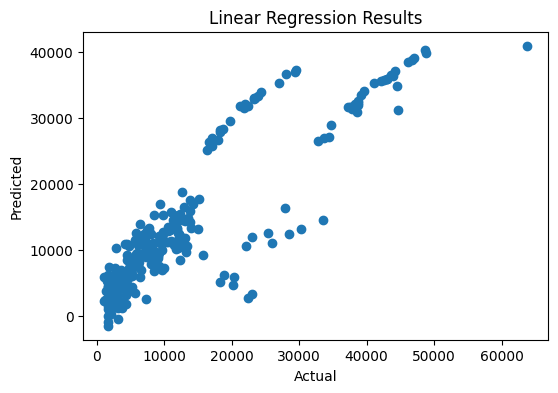

In [116]:
plt.figure(figsize=(6,4))
plt.scatter(y_test, y_pred_lr)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Linear Regression Results")
plt.show()

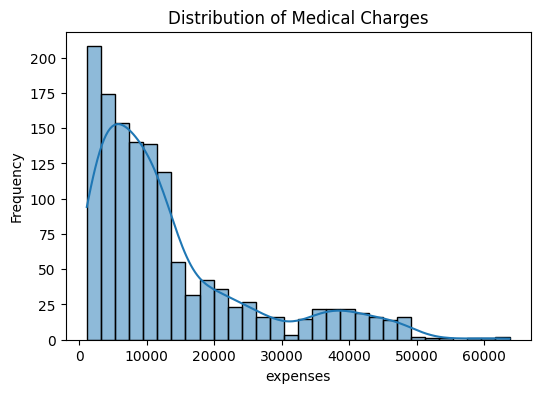

In [117]:
plt.figure(figsize=(6,4))
sns.histplot(df['expenses'], kde=True)
plt.title("Distribution of Medical Charges")
plt.xlabel("expenses")
plt.ylabel("Frequency")
plt.show()


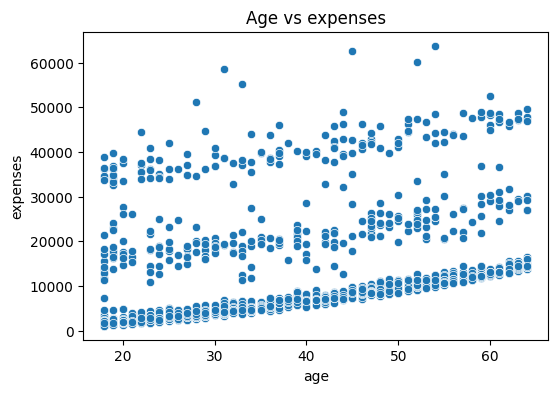

In [118]:
plt.figure(figsize=(6,4))
sns.scatterplot(x='age', y='expenses', data=df)
plt.title("Age vs expenses")
plt.show()

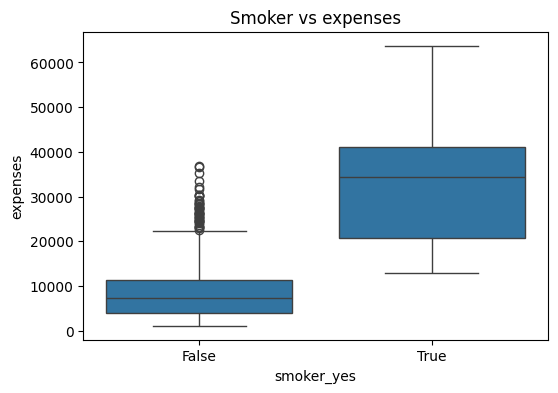

In [119]:
plt.figure(figsize=(6,4))
sns.boxplot(x='smoker_yes', y='expenses', data=df)
plt.title("Smoker vs expenses")
plt.show()

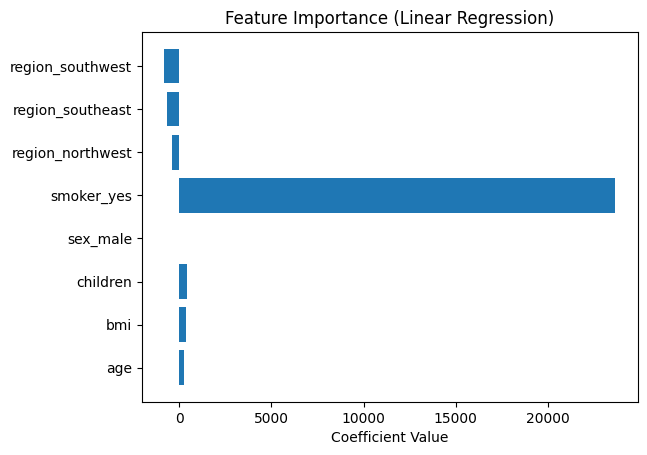

In [120]:
importance = lr.coef_
features = X.columns

plt.barh(features, importance)
plt.title("Feature Importance (Linear Regression)")
plt.xlabel("Coefficient Value")
plt.show()

In [121]:
#Among all models, Polynomial Regression achieved the highest R2 score,
#indicating better performance in capturing non-linear relationships.
#Regularization models like Ridge and Lasso helped in reducing overfitting.

FINAL CONCLUSION

In [122]:
## Final Conclusion

#In this project, multiple regression models were implemented to predict medical expenses.

#Polynomial Regression performed the best with highest R2 Score,
#indicating strong ability to capture non-linear relationships.

#Regularization techniques like Ridge, Lasso, and ElasticNet
#helped in reducing overfitting and improving model generalization.